# Sotfmax Distribution

In [1]:
import jax.numpy as jnp
import jax
import seaborn as sns
import matplotlib.pyplot as plt

# from probml_utils import latexify, savefig, is_latexify_enabled

from scipy.stats import binom

In [2]:
def softmax(a):
    e = jnp.exp((1.0 * jnp.array(a)))
    return e / jnp.sum(e)

In [3]:
def plot_softmax_distribution(T, a, save_name, fig=None, axs=None):
    ind = jnp.arange(1, len(a) + 1)
    fig, axs = plt.subplots(1, len(T), sharey="row")

    axs[0].set_ylabel(r"$S(a | T)$")
    for i, ax in enumerate(axs):
        ax.bar(ind, softmax(a / T[i]))

        ax.set_xlabel("logits (a)")
        ax.set_ylim(0, 1)
        ax.set_title(f"T = {T[i]}")

    sns.despine()
    plt.tight_layout()

    # if len(save_name) > 0:
    #     savefig(save_name)

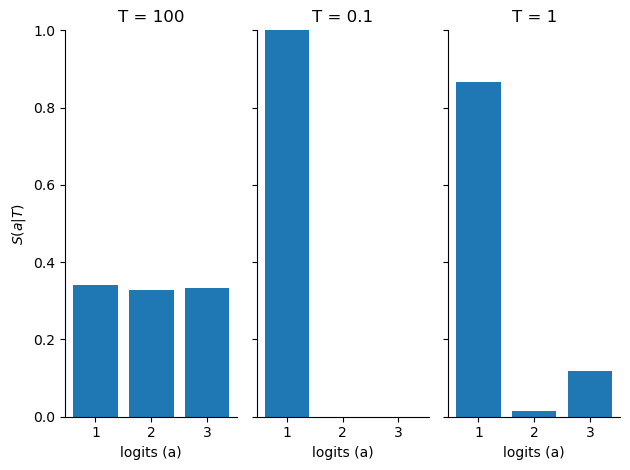

In [15]:
T_array = [100, 0.1, 1]
a = jnp.array([3, -1, 1])

plot_softmax_distribution(T_array, a, f"softmax_temp")

### Interactive figure for softmax distribution

In [16]:
from ipywidgets import interact


@interact(T=(1, 100))
def generate_interactinve_graph(T):
    a = jnp.array([3, 0, 1])
    ind = jnp.arange(1, len(a) + 1)

    plt.figure()
    plt.bar(ind, softmax(a / T))
    plt.title(f"T = {T}")
    plt.ylim(0, 1)
    plt.xlabel("logits (a)")
    plt.ylabel("$S(a | T)$")
    sns.despine()

interactive(children=(IntSlider(value=50, description='T', min=1), Output()), _dom_classes=('widget-interact',…